Script: loads the EOF, regresses on 500mb geopotential height, then plots panels - similar to O'Brien & Deser Figure S1
Note this is done for EOFs in time not the SEOF
Notes: needs to be run individually for each model - check the boxes that have a *change me* tag on the top. 

Output files:
FS1bdata_zgNPac_time
FS1bdata_zgTPac_time
FS1bdata_zgNA_time

In [2]:
#load packages needed in this notebook
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
from eofs.standard import Eof
import regionmask
import cartopy.crs as ccrs
from matplotlib import pyplot as PP
import copy
import matplotlib as mpl
import matplotlib.patches as mpatches
from cartopy.util import add_cyclic_point

In [3]:
#define linear regression function

def linregress_3D(x, y):
    """

    Input:
    x: one dimentional array to regress against
    y: 3 dimentionsal array (time,lat,lon)

    the first dimention of y must be the same length of x

    return: slope,intercept,pval,cor,stderr,cov on regression
    between the two datasets along their aligned dimension.

    The output format and data are exactly identical to numpy's linregress

    """

    # broadcast the input x array to be the same shape as input y array
    x = np.array(np.broadcast_to(x[:,np.newaxis,np.newaxis],y.shape))

    # mask invalid locations in y
    ym = np.ma.masked_invalid(y)
    # apply the same mask to x
    xm = np.ma.masked_array(x, mask=ym.mask)

    #3. Compute data length, mean and standard deviation along time axis for further use:
    n     = xm.shape[0]
    xmean = xm.mean(axis=0)
    ymean = ym.mean(axis=0)
    xstd  = xm.std(axis=0)
    ystd  = ym.std(axis=0)

    #4. Compute covariance along time axis
    cov   =  np.sum(np.multiply((xm - xmean),(ym - ymean)), axis=0)/(n-1)
    #covxx   =  np.sum(np.multiply((xm - xmean),(xm - xmean).T), axis=0)/(n-1)
    #covyy   =  np.sum(np.multiply((ym - ymean),(ym - ymean).T), axis=0)/(n-1)
    #print(cov.shape)

    #5. Compute correlation along time axis
    cor   = cov/(xstd*ystd)

    #6. Compute regression slope and intercept:
    slope     = cov/(xstd**2)
    intercept = ymean - xmean*slope

    #7. Compute P-value and standard error
    # Compute t-statistics
    TINY = 1.0e-20
    tstats = cor*np.sqrt((n-2)/((1.0 - cor + TINY)*(1.0 + cor + TINY)))
    stderr = slope/tstats

    df = n-2
    #stderr = np.sqrt((1 - cor**2) * covxx / covyy / df)

    from scipy.stats import t
    pval   = 2*t.sf(x=np.abs(tstats), df=df)
    #pval   = xr.DataArray(pval, dims=cor.dims, coords=cor.coords)

    return slope, intercept, cor, pval, stderr

In [4]:
#*change me*

#set up the data directory and load in lon + lat + time dimensions
outputdir='/glade/campaign/cgd/cas/nmaher/cesm1_lens/Amon/zg/' 
outputdir2b='/glade/work/nmaher/SEOF_output/Fig_data/'
outputdir2='/glade/work/nmaher/SEOF_output/'

model='CESM1-LE'


#tell me when the start year is 
syear=1920

offset=1950-syear
#load lon lat should be same for all models
ds_fx = xr.open_dataset(outputdir+'zg_Amon_CESM1-CAM5_historical_rcp85_r10i1p1_192001-210012_g025.nc')

lon = ds_fx.lon
lat = ds_fx.lat

In [5]:
model

'CESM1-LE'

In [6]:
#load data from PNA SEOF and from the saved DJF zg500 files

eof_T='_PNA'

with np.load(outputdir2b+model+eof_T+'_SPCS_time.npz') as npz:
    pna_spcs = np.ma.MaskedArray(**npz)
with np.load(outputdir2b+model+eof_T+'_SEOF_time.npz') as npz:
    pna_seof = np.ma.MaskedArray(**npz)

eof_T='_zgDJFerem'
with np.load(outputdir2+model+eof_T+'_SEOF.npz') as npz:
    zg_DJF_2e_full2 = np.ma.MaskedArray(**npz)
    
eof_T='_zgDJF'
with np.load(outputdir2+model+eof_T+'_SEOF.npz') as npz:
    zg_DJF_2_full = np.ma.MaskedArray(**npz)    

In [7]:
pna_spcs.shape

(40, 65, 3)

In [8]:
pna_seof.shape

(40, 3, 72, 144)

In [9]:
#tell me how many eofs and length of time dimension

neof=3
ntt=len(pna_spcs[:,1,1])

In [10]:
#load the SST data
eof_T='_tosDJFerem'
with np.load(outputdir2+model+eof_T+'_SEOF.npz') as npz:
    tos_DJF_2e_full = np.ma.MaskedArray(**npz)

In [11]:
zg_DJF_2e_full2b=zg_DJF_2e_full2[:,0+offset:66+offset,:,:]
zg_DJF_2e_full=zg_DJF_2e_full2b[:,1:,:,:]

In [12]:
#make sure the EOFs are all in the right direction 
pattCorr_array = np.ma.masked_equal(np.zeros([neof,ntt]),0)

for i in range(ntt):

    eof0a = pna_seof[0,0,...].flatten() - pna_seof[0,0,...].mean()
    eof1a = pna_seof[i,0,...].flatten() - pna_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr_array[0,i] = num
    eof0b = pna_seof[0,1,...].flatten() - pna_seof[0,1,...].mean()
    eof1b = pna_seof[i,1,...].flatten() - pna_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr_array[1,i] = numb
    eof0c = pna_seof[0,2,47:65,0:140].flatten() - pna_seof[0,2,47:65,0:140].mean()
    eof1c = pna_seof[i,2,47:65,0:140].flatten() - pna_seof[i,2,47:65,0:140].mean()
    numc = np.sum(eof0c*eof1c)/np.sqrt(np.sum(eof0c**2)*np.sum(eof1c**2))
    pattCorr_array[2,i] = numc

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

pna_seof_tmp = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)
pna_seof_phcorr = np.ma.masked_array(pna_seof,mask=pna_seof.mask,copy=True)

pna_spcs_tmp = np.array(pna_spcs,copy=True)
pna_spcs_phcorr = np.array(pna_spcs,copy=True)


# flip seofs/spcs 0

# get the indices with negitive/positive correlations.
# note here it turns out that the first seof I was correlating against
# had the incorrect phase so Im flipping all the positive phased ones
# to avoid doing this (it doesnt matter much tbh) just set the phase of the first
# seof to what you want it before calculating the pattern correlations

ineg = np.nonzero(pattCorr_array[0,:]>0)[0]

pna_seof_phcorr[ineg,0,...] = -1*pna_seof_tmp[ineg,0,...]
pna_spcs_phcorr[ineg,:,0] = -1*pna_spcs_tmp[ineg,:,0]


# flip seofs/spcs 1

ineg = np.nonzero(pattCorr_array[1,:]>0)[0]

pna_seof_phcorr[ineg,1,...] = -1*pna_seof_tmp[ineg,1,...]
pna_spcs_phcorr[ineg,:,1] = -1*pna_spcs_tmp[ineg,:,1]


# flip seofs/spcs 2

ineg = np.nonzero(pattCorr_array[2,:]>0)[0]

pna_seof_phcorr[ineg,2,...] = -1*pna_seof_tmp[ineg,2,...]
pna_spcs_phcorr[ineg,:,2] = -1*pna_spcs_tmp[ineg,:,2]

In [13]:
# now regess the phase corrected seof principal components against the z500 ensemble dimension

z500_spc_ens_reg_slopes = np.ma.masked_equal(np.zeros((neof,ntt,72,144)),0)
z500_spc_ens_reg_pvals = np.ma.masked_equal(np.zeros((neof,ntt,72,144)),0)
z500_spc_ens_reg_corrcoef = np.ma.masked_equal(np.zeros(( neof,ntt,72,144)),0)


for j in range(neof):

    for i in range(ntt)[:]:

        z500_rs = zg_DJF_2e_full[i,:,...]#.reshape(-1,72,144)

        z_ens_pc_reg = linregress_3D(pna_spcs_phcorr[i,:,j], z500_rs)
        z500_spc_ens_reg_slopes[j,i,...] = z_ens_pc_reg[0]
        z500_spc_ens_reg_pvals[j,i,...] = z_ens_pc_reg[3]
        z500_spc_ens_reg_corrcoef[j,i,...] = z_ens_pc_reg[2]

In [14]:
#load the North Atlantic SEOFs

eof_T='_NAT'

with np.load(outputdir2b+model+eof_T+'_SPCS_time.npz') as npz:
    nat_spcs = np.ma.MaskedArray(**npz)
with np.load(outputdir2b+model+eof_T+'_SEOF_time.npz') as npz:
    nat_seof = np.ma.MaskedArray(**npz)

neof=1    

In [15]:
#make sure the EOFs are all in the right direction 
pattCorr_array = np.ma.masked_equal(np.zeros([neof,ntt]),0)

for i in range(ntt):

    eof0a = nat_seof[0,0,...].flatten() - nat_seof[0,0,...].mean()
    eof1a = nat_seof[i,0,...].flatten() - nat_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr_array[0,i] = num

'''
after you poplulate the pattern corr array. use it like so to flip all the
spcs with negitive correlations
'''

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

nat_seof_tmp = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)
nat_seof_phcorr = np.ma.masked_array(nat_seof,mask=nat_seof.mask,copy=True)

nat_spcs_tmp = np.array(nat_spcs,copy=True)
nat_spcs_phcorr = np.array(nat_spcs,copy=True)


# flip seofs/spcs 0

# get the indices with negitive/positive correlations.
# note here it turns out that the first seof I was correlating against
# had the incorrect phase so Im flipping all the positive phased ones
# to avoid doing this (it doesnt matter much tbh) just set the phase of the first
# seof to what you want it before calculating the pattern correlations

ineg = np.nonzero(pattCorr_array[0,:]>0)[0]

nat_seof_phcorr[ineg,0,...] = -1*nat_seof_tmp[ineg,0,...]
nat_spcs_phcorr[ineg,:,0] = -1*nat_spcs_tmp[ineg,:,0]


In [16]:
# now regess the phase corrected seof principal components against the z500 ensemble dimension

z500_nat_ens_reg_slopes = np.ma.masked_equal(np.zeros((neof,ntt,72,144)),0)
z500_nat_ens_reg_pvals = np.ma.masked_equal(np.zeros((neof,ntt,72,144)),0)
z500_nat_ens_reg_corrcoef = np.ma.masked_equal(np.zeros(( neof,ntt,72,144)),0)

for j in range(neof):

    for i in range(ntt)[:]:

        z500_rs = zg_DJF_2e_full[i,:,...].reshape(-1,72,144)

        z_ens_pc_reg = linregress_3D(nat_spcs_phcorr[i,:,j], z500_rs)
        z500_nat_ens_reg_slopes[j,i,...] = z_ens_pc_reg[0]
        z500_nat_ens_reg_pvals[j,i,...] = z_ens_pc_reg[3]
        z500_nat_ens_reg_corrcoef[j,i,...] = z_ens_pc_reg[2]

In [17]:
z500_nat_ens_reg_slopes.shape

(1, 40, 72, 144)

In [18]:
#load the Tropical Pacific SEOFs

eof_T='_TPAC_SST'

with np.load(outputdir2b+model+eof_T+'_SPCS_time.npz') as npz:
    tpac_spcs = np.ma.MaskedArray(**npz)
with np.load(outputdir2b+model+eof_T+'_SEOF_time.npz') as npz:
    tpac_seof = np.ma.MaskedArray(**npz)

neof=2    

In [19]:
#make sure the EOFs are all in the right direction 
pattCorr_array = np.ma.masked_equal(np.zeros([neof,ntt]),0)

for i in range(ntt):

    eof0a = tpac_seof[0,0,...].flatten() - tpac_seof[0,0,...].mean()
    eof1a = tpac_seof[i,0,...].flatten() - tpac_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr_array[0,i] = num
    eof0b = tpac_seof[0,1,...].flatten() - tpac_seof[0,1,...].mean()
    eof1b = tpac_seof[i,1,...].flatten() - tpac_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr_array[1,i] = numb

'''
after you poplulate the pattern corr array. use it like so to flip all the
spcs with negitive correlations
'''

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

tpac_seof_tmp = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)
tpac_seof_phcorr = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)

tpac_spcs_tmp = np.array(tpac_spcs,copy=True)
tpac_spcs_phcorr = np.array(tpac_spcs,copy=True)


# flip seofs/spcs 0

# get the indices with negitive/positive correlations.
# note here it turns out that the first seof I was correlating against
# had the incorrect phase so Im flipping all the positive phased ones
# to avoid doing this (it doesnt matter much tbh) just set the phase of the first
# seof to what you want it before calculating the pattern correlations

ineg = np.nonzero(pattCorr_array[0,:]>0)[0]

tpac_seof_phcorr[ineg,0,...] = -1*tpac_seof_tmp[ineg,0,...]
tpac_spcs_phcorr[ineg,:,0] = -1*tpac_spcs_tmp[ineg,:,0]


# flip seofs/spcs 1

ineg = np.nonzero(pattCorr_array[1,:]>0)[0]

tpac_seof_phcorr[ineg,1,...] = -1*tpac_seof_tmp[ineg,1,...]
tpac_spcs_phcorr[ineg,:,1] = -1*tpac_spcs_tmp[ineg,:,1]


In [20]:
# now regess the phase corrected seof principal components against the z500 ensemble dimension

z500_tpac_ens_reg_slopes = np.ma.masked_equal(np.zeros((neof,ntt,72,144)),0)
z500_tpac_ens_reg_pvals = np.ma.masked_equal(np.zeros((neof,ntt,72,144)),0)
z500_tpac_ens_reg_corrcoef = np.ma.masked_equal(np.zeros(( neof,ntt,72,144)),0)

# 4 is the number of spcs# 176 is the number of spc time steps
for j in range(neof):

    for i in range(ntt)[:]:

        z500_rs = zg_DJF_2e_full[i,:,...].reshape(-1,72,144)

        z_ens_pc_reg = linregress_3D(tpac_spcs_phcorr[i,:,j], z500_rs)
        z500_tpac_ens_reg_slopes[j,i,...] = z_ens_pc_reg[0]
        z500_tpac_ens_reg_pvals[j,i,...] = z_ens_pc_reg[3]
        z500_tpac_ens_reg_corrcoef[j,i,...] = z_ens_pc_reg[2]

In [21]:
#*change me* - note if you don't run CESM1 first you need to change the next cell 

#flip to the sign to match JP paper - run this for CESM1-LE only
#z500_spc_ens_reg_slopes[1,:,:,:]=z500_spc_ens_reg_slopes[1,:,:,:]*-1
#z500_spc_ens_reg_slopes[2,:,:,:]=z500_spc_ens_reg_slopes[2,:,:,:]*-1

#z500_tpac_ens_reg_slopes[0,:,:,:]=z500_tpac_ens_reg_slopes[0,:,:,:]*-1

#save for CESM1 to use to flip all additional models the same way
#np.savez_compressed(outputdir2+model+'_pna_reg_slope.npz', data=z500_spc_ens_reg_slopes.data)
#np.savez_compressed(outputdir2+model+'_nat_reg_slope.npz', data=z500_nat_ens_reg_slopes.data)
#np.savez_compressed(outputdir2+model+'_tpac_reg_slope.npz', data=z500_tpac_ens_reg_slopes.data)


In [22]:
#other models load in CESM1 - correlate and decide to flip

model2='CESM1-LE'

with np.load(outputdir2+model2+'_pna_reg_slope.npz') as npz:
    pna_cesm = np.ma.MaskedArray(**npz)
with np.load(outputdir2+model2+'_nat_reg_slope.npz') as npz:
    nat_cesm = np.ma.MaskedArray(**npz)
with np.load(outputdir2+model2+'_tpac_reg_slope.npz') as npz:
    tpac_cesm = np.ma.MaskedArray(**npz)   
    



In [23]:
#do the flipping to match CESM1

eof0a = pna_cesm[0,0,...].flatten() 
eof1a = z500_spc_ens_reg_slopes[0,0,:,:].flatten() 
num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
if num<0:
    z500_spc_ens_reg_slopes[0,:,:,:]=z500_spc_ens_reg_slopes[0,:,:,:]*-1
    
eof0a = pna_cesm[1,0,...].flatten() 
eof1a = z500_spc_ens_reg_slopes[1,0,:,:].flatten() 
num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
if num<0:
    z500_spc_ens_reg_slopes[1,:,:,:]=z500_spc_ens_reg_slopes[1,:,:,:]*-1
    
eof0a = pna_cesm[2,0,...].flatten() 
eof1a = z500_spc_ens_reg_slopes[2,0,:,:].flatten() 
num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
if num<0:
    z500_spc_ens_reg_slopes[2,:,:,:]=z500_spc_ens_reg_slopes[2,:,:,:]*-1  
    
eof0a = nat_cesm[0,0,...].flatten() 
eof1a = z500_nat_ens_reg_slopes[0,0,:,:].flatten() 
num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
if num<0:
    z500_nat_ens_reg_slopes[0,:,:,:]=z500_nat_ens_reg_slopes[0,:,:,:]*-1
    
eof0a = tpac_cesm[0,0,...].flatten() 
eof1a = z500_tpac_ens_reg_slopes[0,0,:,:].flatten() 
num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
if num<0:
    z500_tpac_ens_reg_slopes[0,:,:,:]=z500_tpac_ens_reg_slopes[0,:,:,:]*-1
    
eof0a = tpac_cesm[1,0,...].flatten() 
eof1a = z500_tpac_ens_reg_slopes[1,0,:,:].flatten() 
num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
if num<0:
    z500_tpac_ens_reg_slopes[1,:,:,:]=z500_tpac_ens_reg_slopes[1,:,:,:]*-1    

In [24]:
#save the data that goes into the Figure for easy access
outputdir_figD='/glade/work/nmaher/SEOF_output/Fig_data/'

eof_T='_FS1bdata_zgNPac_time'
np.savez_compressed(outputdir_figD+model+eof_T+'.npz', data=z500_spc_ens_reg_slopes.data)

eof_T='_FS1bdata_zgTPac_time'
np.savez_compressed(outputdir_figD+model+eof_T+'.npz', data=z500_tpac_ens_reg_slopes.data)

eof_T='_FS1bdata_zgNAt_time'
np.savez_compressed(outputdir_figD+model+eof_T+'.npz', data=z500_nat_ens_reg_slopes.data)

In [25]:
np.max(z500_tpac_ens_reg_slopes)
z500_tpac_ens_reg_slopes.shape


(2, 40, 72, 144)

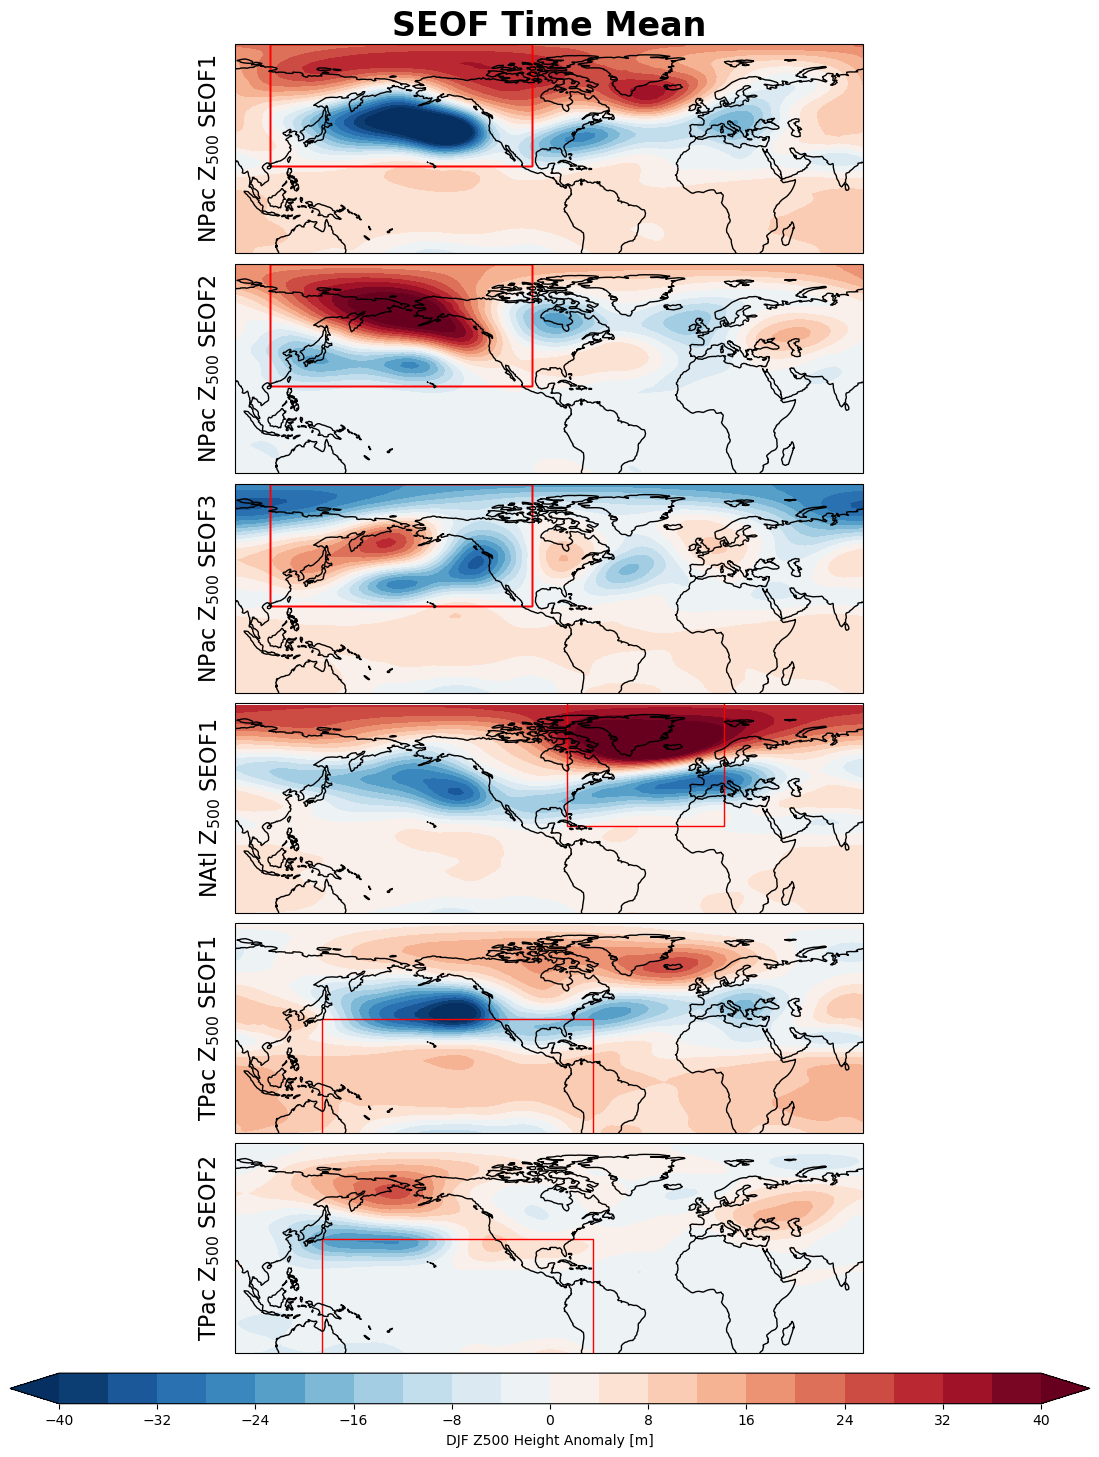

In [26]:
####### code for the z500 8-panel plot

# make the z500 8-panel plot
fig,axs = PP.subplots(6,1,figsize=(18,17), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=270)})

#set up colours and levels
levels = np.linspace(-40,40,21)
clevels = np.arange(5000,6000,100)
cmap = copy.deepcopy(mpl.cm.RdBu_r)


# define 2d lat and lon points for ploting sig locs
lons=lon
lats=lat
lon2d,lat2d = np.meshgrid(lons,lats)

cnt=0

for i in range(3): 

    # plot for 1930
    #cdataE,clons = add_cyclic_point(z500_spc_ens_reg_slopes[i,0set:10+offset,...].mean(axis=0),lons)
    cdataE,clons = add_cyclic_point(z500_spc_ens_reg_slopes[i,0,...],lons)
   
    cplt = axs[i].contourf(clons,lats,cdataE, transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')
    #cdataC,clons2 = add_cyclic_point(zg_contours2,lons)
    #cplt = axs[i,0].contour(clons2,lats,cdataC, transform=ccrs.PlateCarree(), levels=clevels, cmap='binary',extend='both')


    axs[i].coastlines()
    axs[i].set_ylim(-30,90)

    
for i in range(1): 

    # plot for 1930
    cdataE,clons = add_cyclic_point(z500_nat_ens_reg_slopes[i,0,...],lons)
    cplt = axs[i+3].contourf(clons,lats,cdataE, transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')

    axs[i+3].coastlines()
    axs[i+3].set_ylim(-30,90)
 

for i in range(2): 

    # plot for 1930
    cdataE,clons = add_cyclic_point(z500_tpac_ens_reg_slopes[i,0,...],lons)
    cplt = axs[i+4].contourf(clons,lats,cdataE, transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')


    axs[i+4].coastlines()
    axs[i+4].set_ylim(-30,90)


PP.text(-0.04,0.5,'NPac Z$_{500}$ SEOF1', rotation=90, fontsize=16, ha='center', va='center', transform=axs[0].transAxes)
PP.text(-0.04,0.5,'NPac Z$_{500}$ SEOF2', rotation=90, fontsize=16, ha='center', va='center', transform=axs[1].transAxes)
PP.text(-0.04,0.5,'NPac Z$_{500}$ SEOF3', rotation=90, fontsize=16, ha='center', va='center', transform=axs[2].transAxes)
PP.text(-0.04,0.5,'NAtl Z$_{500}$ SEOF1', rotation=90, fontsize=16, ha='center', va='center', transform=axs[3].transAxes)
PP.text(-0.04,0.5,'TPac Z$_{500}$ SEOF1', rotation=90, fontsize=16, ha='center', va='center', transform=axs[4].transAxes)
PP.text(-0.04,0.5,'TPac Z$_{500}$ SEOF2', rotation=90, fontsize=16, ha='center', va='center', transform=axs[5].transAxes)

axs[0].set_title('SEOF Time Mean', fontsize=24, weight='bold')


PP.subplots_adjust(hspace=0.05,wspace=0.05)

cticks = np.linspace(-1,1,21)

cbar_ax = fig.add_axes([0.213, 0.08, 0.6, 0.018])

cbar = fig.colorbar(cplt, cax=cbar_ax, orientation='horizontal', ticks=levels[::2])
cbar.set_label(r'DJF Z500 Height Anomaly [m]')

# draw NPac Bnds

lat_range=[20,90]
lon_range=[110,260]

lat_height = lat_range[-1]-lat_range[0]
lon_width = lon_range[-1]-lon_range[0]

for i in range(3):
    for j in range(3):

        # NPac bnds
        axs[i].add_patch(mpatches.Rectangle(xy=[lon_range[0],lat_range[0]], width=lon_width, height=lat_height,\
                                edgecolor='red',\
                                alpha=1,\
                                fill=False,\
                                transform=ccrs.PlateCarree()))

# draw NAtl Bnds

lat_range=[20,90]
lon_range=[280,10]

lat_height = lat_range[-1]-lat_range[0]
lon_width = lon_range[-1]-lon_range[0]+360

for i in range(1):
    for j in range(1):

        # NAtl bnds
        axs[i+3].add_patch(mpatches.Rectangle(xy=[lon_range[0],lat_range[0]], width=lon_width, height=lat_height,\
                                edgecolor='red',\
                                alpha=1,\
                                fill=False,\
                                transform=ccrs.PlateCarree()))
        
# draw Tpac Bnds



#pna = 110-260 20N 90N
#nat = 80w 10E same above
#tpac = 35s 35n 140-295e

lat_range=[-35,35]
lon_range=[140,295]

lat_height = lat_range[-1]-lat_range[0]
lon_width = lon_range[-1]-lon_range[0]

for i in range(2):
    for j in range(1):

        # NPac bnds
        axs[i+4].add_patch(mpatches.Rectangle(xy=[lon_range[0],lat_range[0]], width=lon_width, height=lat_height,\
                                edgecolor='red',\
                                alpha=1,\
                                fill=False,\
                                transform=ccrs.PlateCarree()))


#PP.savefig(outputdir2+model+'FigureS1b.png', dpi=300, bbox_inches='tight')

PP.show()